# **INTRODUCTION**

This assignment focuses on Model Tuning and Validation.The aim is to improve the model's performance,ensure it generalizes well to unseen data and reduce the risk of overfitting and underfitting.I will use a dataset from  the National Institute of Diabetes and Digestive and Kidney Diseases to diagnostically predict wether or not a patient has diabetes based on certain measurements included in the dataset.

For this project :

0: person does not have diabetes

1:person has diabetes

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,roc_auc_score,root_mean_squared_error,f1_score

In [2]:
from google.colab import files
uploaded=files.upload()

Saving diabetes.csv to diabetes.csv


In [3]:
df=pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.shape

(768, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
(df==0).sum()

,0
Pregnancies,111
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,500


# **MISSING VALUES**

The dataset has some missing values in some columns like insulin,BMI,skin thickness,Blood preassure,Glucose.columns such as Outcome and pregnancies also have some 0 values but they will be retained because they represent valid observations.

In [7]:
columns_with_missing=[
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]
df[columns_with_missing]=df[columns_with_missing].replace(0,np.nan)

In [8]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   763 non-null    float64
 2   BloodPressure             733 non-null    float64
 3   SkinThickness             541 non-null    float64
 4   Insulin                   394 non-null    float64
 5   BMI                       757 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


In [10]:
df["Pregnancies"].value_counts()

,count
Pregnancies,
1,135
0,111
2,103
3,75
4,68
5,57
6,50
7,45
8,38


In [11]:
df["Outcome"].value_counts()

,count
Outcome,
0,500
1,268


# **IMPUTATION**

Now that we have separated zeros which represent valid observations to invalid zeros we will then move on to missing value treatment and for this dataset i will use median imputation because medical observations tend to have skewed distrubutions and outliers and the median gives a more typical value without being pulled much by extreme observations.

In [12]:
df[columns_with_missing].head()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI
0,148.0,72.0,35.0,NaN,33.6
1,85.0,66.0,29.0,NaN,26.6
2,183.0,64.0,NaN,NaN,23.3
3,89.0,66.0,23.0,94.0,28.1
4,137.0,40.0,35.0,168.0,43.1


In [13]:
print("Reloading the dataset to correct previous accidental NaN replacement...")
df = pd.read_csv("diabetes.csv")

# Re-check the initial zeros before specific NaN replacement
print("Initial count of zeros in relevant columns:")
print(df[columns_with_missing].isin([0]).sum())

Reloading the dataset to correct previous accidental NaN replacement...
Initial count of zeros in relevant columns:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [14]:
# Now, correctly replace 0s with NaN in the identified columns
columns_to_replace_zeros = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]
df[columns_to_replace_zeros] = df[columns_to_replace_zeros].replace(0, np.nan)

print("\nNull counts after replacing 0s with NaN:")
display(df[columns_to_replace_zeros].isnull().sum().to_frame(name='NaN Count'))


Null counts after replacing 0s with NaN:


,NaN Count
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


In [15]:
# Apply median imputation, ensuring robust handling of columns
for col in columns_to_replace_zeros:
    if df[col].isnull().any(): # Only try to fill if there are NaNs
        median_val = df[col].median()
        if pd.isna(median_val):
            print(f"Warning: Column '{col}' is entirely NaN, skipping median imputation for this column.")
        else:
            df[col] = df[col].fillna(median_val)
            print(f"Filled NaN values in '{col}' with median: {median_val:.2f}")
    else:
        print(f"Column '{col}' has no NaN values to fill.")

Filled NaN values in 'Glucose' with median: 117.00
Filled NaN values in 'BloodPressure' with median: 72.00
Filled NaN values in 'SkinThickness' with median: 29.00
Filled NaN values in 'Insulin' with median: 125.00
Filled NaN values in 'BMI' with median: 32.30


In [16]:
print("\nFirst 5 rows of the DataFrame after imputation:")
display(df.head())

print("\nFinal null counts after imputation:")
display(df[columns_to_replace_zeros].isnull().sum().to_frame(name='NaN Count'))


First 5 rows of the DataFrame after imputation:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1



Final null counts after imputation:


,NaN Count
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0


In [17]:
display(df.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


# **EXPLORATORY DATA ANALYSIS(EDA)**

In [18]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


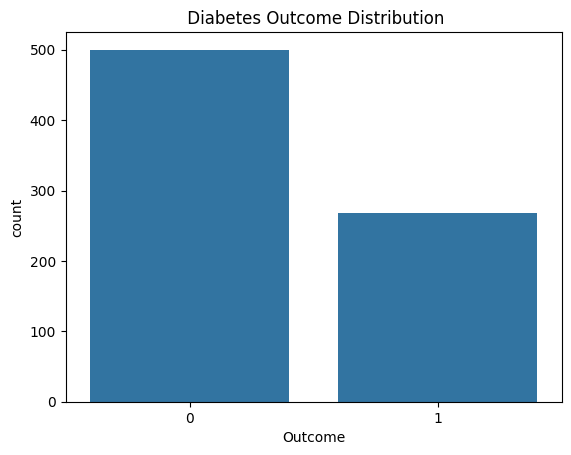

In [19]:
sns.countplot(x="Outcome",data=df)
plt.title(" Diabetes Outcome Distribution")
plt.show()

# **CLASS IMBALANCE**

The target variable Outcome showed moderate class imbalance of 65.1% and 34.9%, with more non diabetic cases than diabetic cases.To address this a stratified train-test split will be applied to preserve class distribution.

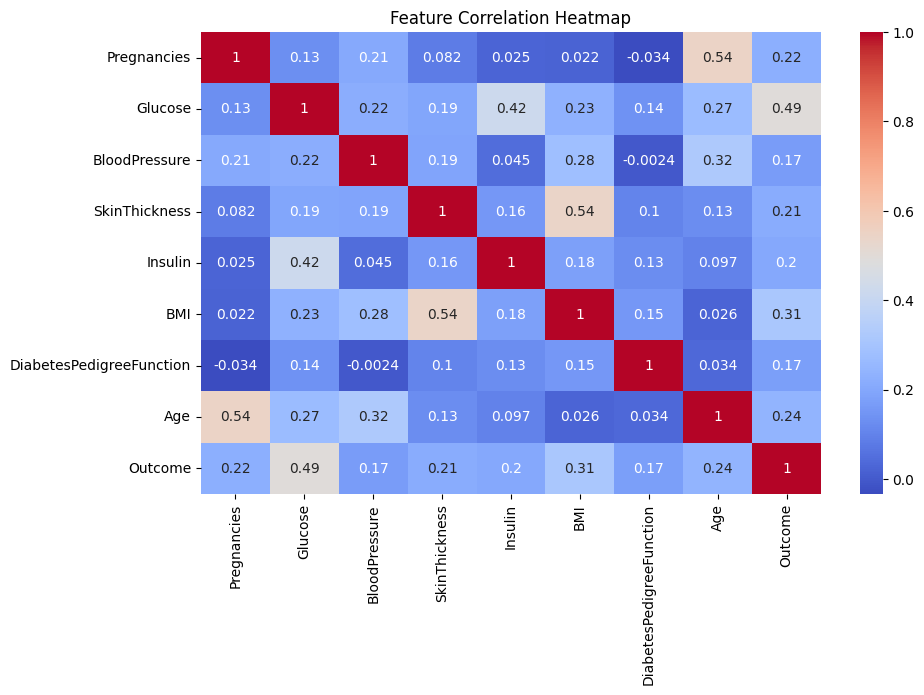

In [20]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True,
            cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [21]:
x=df.drop("Outcome",axis=1)
y=df["Outcome"]

In [22]:
x.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33


In [23]:
y.head()

,Outcome
0,1
1,0
2,1
3,0
4,1


In [24]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,stratify=y,random_state=42
)


In [25]:
print("Training set")
print(y_train.value_counts(normalize=True))
print("\nTesting set")
print(y_test.value_counts(normalize=True))

Training set
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Testing set
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


# **BASELINE MODEL:LOGISTIC REGRESSION**

We will the logistic regression model as a baseline with balanced class weights for the class imbalance.

In [26]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

In [27]:
baseline_model=LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

In [28]:
baseline_model.fit(x_train,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [29]:
baseline_pred=baseline_model.predict(x_test)

#EVALUATION OF THE BASELINE

In [30]:
baseline_accuracy=accuracy_score(y_test,baseline_pred)
baseline_precision=precision_score(y_test,baseline_pred)
baseline_recall=recall_score(y_test,baseline_pred)
baseline_f1=f1_score(y_test,baseline_pred)
baseline_roc_auc=roc_auc_score(y_test,baseline_pred)

print("Accuracy:",baseline_accuracy)
print("Precision:",baseline_precision)
print("Recall:",baseline_recall)
print("F1 Score:",baseline_f1)
print("ROC AUC Score:",baseline_roc_auc)

Accuracy: 0.7337662337662337
Precision: 0.6031746031746031
Recall: 0.7037037037037037
F1 Score: 0.6495726495726496
ROC AUC Score: 0.7268518518518519


# **BASELINE PERFORMANCE**

The Logistic Regression baseline achieved an accuracy of 73.38%, indicating that the model correctly classified approximately 73% of the test samples. The model achieved a recall of 70.37%, meaning it was able to identify a substantial proportion of patients with diabetes. However, the precision score of 60.32% suggests that some patients were incorrectly classified as diabetic.

The ROC-AUC score of 0.7269 indicates that the model has a fair ability to distinguish between diabetic and non-diabetic patients. Although the baseline model provides reasonable predictive performance, there is potential for improvement using more complex algorithms and hyperparameter optimization.

Logistic Regression was established as the baseline model for comparison. The model provides a benchmark against which the performance of optimized models, such as Random Forest after hyperparameter tuning, will be evaluated.

# **RANDOM FOREST CLASSIFIER**


In [31]:
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier(random_state=42)
class_weight="balanaced"

In [32]:
rf_model.fit(x_train,y_train)
rf_pred=rf_model.predict(x_test)

In [33]:
rf_accuracy=accuracy_score(y_test,rf_pred)
rf_precision=precision_score(y_test,rf_pred)
rf_recall=recall_score(y_test,rf_pred)
rf_f1=f1_score(y_test,rf_pred)
rf_roc_auc=roc_auc_score(y_test,rf_pred)

print("Accuracy:",rf_accuracy)
print("Precision:",rf_precision)
print("Recall:",rf_recall)
print("F1 Score:",rf_f1)
print("ROC AUC Score:",rf_roc_auc)

Accuracy: 0.7792207792207793
Precision: 0.7272727272727273
Recall: 0.5925925925925926
F1 Score: 0.6530612244897959
ROC AUC Score: 0.7362962962962963


# **LOGISTIC REGRESSION (BASELINE) VS RANDOM FOREST CLASSIFIER**

The default Random Forest model achieved better overall performance compared to Logistic Regression:

Accuracy increased from 73.38% to 77.92%, showing that Random Forest classified more patients correctly.
Precision improved from 60.32% to 72.73%, meaning that when the model predicted diabetes, it was more often correct.
ROC-AUC improved slightly from 0.7269 to 0.7363, indicating better discrimination between diabetic and non-diabetic patients.
However, recall decreased from 70.37% to 59.26%, meaning Random Forest identified fewer actual diabetic patients compared to Logistic Regression.
The F1-score remained almost the same (0.6496 vs 0.6531), suggesting a trade-off between precision and recall.


The Random Forest model outperformed Logistic Regression in accuracy, precision, and ROC-AUC, making it a stronger initial model. However, its lower recall indicates that some diabetic cases may be missed. Hyperparameter tuning will be applied to optimize the Random Forest model and improve its ability to generalize to unseen data.

# **RANDOM FOREST CLASSIFIER-TUNED**

In [34]:
param_grid={
    "n_estimators":[100,200,300],
    "max_depth":[None,5,10,15],
    "min_samples_split":[2,5,10],

}

In [35]:
grid_search=GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    verbose=1,
    n_jobs=-1
)



In [36]:
grid_search.fit(x_train,y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10, 15],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy', verbose=1)

In [37]:
print("Best Parameters:",grid_search.best_params_)
print("Best CV Score:",grid_search.best_score_)

Best Parameters: {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score: 0.7736638677862189


In [38]:
best_rf=grid_search.best_estimator_
best_rf_pred=best_rf.predict(x_test)

In [39]:
tuned_rf_accuracy=accuracy_score(y_test,best_rf_pred)
tuned_rf_precision=precision_score(y_test,best_rf_pred)
tuned_rf_recall=recall_score(y_test,best_rf_pred)
tuned_rf_f1=f1_score(y_test,best_rf_pred)
tuned_rf_roc_auc=roc_auc_score(y_test,best_rf_pred)

print("Accuracy:",tuned_rf_accuracy)
print("Precision:",tuned_rf_precision)
print("Recall:",tuned_rf_recall)
print("F1 Score:",tuned_rf_f1)
print("ROC AUC Score:",tuned_rf_roc_auc)

Accuracy: 0.7402597402597403
Precision: 0.6590909090909091
Recall: 0.5370370370370371
F1 Score: 0.5918367346938775
ROC AUC Score: 0.6935185185185185


In [40]:
import pandas as pd

model_comparison = pd.DataFrame({
"Model": [
"Logistic Regression (Baseline)",
"Random Forest (Before Tuning)",
"Random Forest (After Tuning)"
],
"Accuracy": [
0.7338,
0.7792,
0.7403
],
"Precision": [
0.6032,
0.7273,
0.6591
],
"Recall": [
0.7037,
0.5926,
0.5370
],
"F1 Score": [
0.6496,
0.6531,
0.5918
],
"ROC-AUC": [
0.7269,
0.7363,
0.6935
]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression (Baseline),0.7338,0.6032,0.7037,0.6496,0.7269
1,Random Forest (Before Tuning),0.7792,0.7273,0.5926,0.6531,0.7363
2,Random Forest (After Tuning),0.7403,0.6591,0.5370,0.5918,0.6935


# **MODEL PERFORMANCE COMPARISON**
Logistic Regression was first developed as the baseline model to establish a benchmark for diabetes prediction. The model achieved an accuracy of 73.38% and a ROC-AUC score of 0.7269, demonstrating a reasonable ability to distinguish between diabetic and non-diabetic patients. The model achieved a relatively high recall of 70.37%, indicating that it was able to identify a large proportion of actual diabetic cases, although with lower precision.

A Random Forest model was then trained using default parameters and showed improved performance compared to the Logistic Regression baseline. It achieved the highest accuracy (77.92%), precision (72.73%), F1-score (65.31%), and ROC-AUC score (73.63%) among the three models. This suggests that the ensemble approach of combining multiple decision trees helped capture more complex patterns within the dataset.

Hyperparameter tuning was performed on the Random Forest model using Grid Search with 5-fold cross-validation to identify the optimal combination of parameters. However, the tuned Random Forest model did not outperform the default Random Forest model on the independent test set. The tuned model achieved an accuracy of 74.03%, with lower recall, F1-score, and ROC-AUC. This indicates that the original Random Forest configuration generalized better to unseen data.

The results highlight the importance of model validation and the bias-variance tradeoff. While increasing model complexity and optimizing parameters can improve performance, it does not always guarantee better generalization. The default Random Forest model was selected as the best-performing model for this dataset because it provided the strongest balance between accuracy, precision, F1-score, and ROC-AUC while maintaining reliable predictive performance on unseen data.